This notebook demonstrates the performance of the `from_arrays` method for constructing trajectories, compared to `from_instants`.

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point

import sys
sys.path.append("..")

import warnings
import numpy as np
import zipfile
warnings.simplefilter("ignore")
import pymeos
from pymeos import TGeomPointSeq, TGeomPointInst
pymeos.pymeos_initialize()

Here the size of the dataset can be chosen.

In [ ]:
chosen_size = 'small'
sizes = {'small': 100000, 'medium': 1000000, 'large': 5000000}

zip_path = 'data/aisdk-2025-07-11.zip'
csv_filename = 'aisdk-2025-07-11.csv'

n_rows = sizes[chosen_size]

Here we define the extraction and construction functions.

In [11]:
def extraction():
    global df
    with zipfile.ZipFile(zip_path) as archive:        
        with archive.open(csv_filename) as file:
            df = pd.read_csv(file, usecols=['# Timestamp', 'MMSI', 'Latitude', 'Longitude'], nrows=sizes[chosen_size])

    df.rename(columns={'# Timestamp': 't', 'MMSI': 'mmsi', 'Latitude': 'lat', 'Longitude': 'lon'}, inplace=True)
    df = df[df['lat'] <= 90] # default latitude = 91°
    df = df.sort_values(['mmsi', 't'])
    df = df.drop_duplicates(subset=['mmsi', 't'], keep='last')

    global nb_points
    nb_points = df.shape[0]

# extraction()

In [12]:
def construction_from_instants():

    df2 = df.copy()
    df2['geometry'] = [Point(x, y) for x, y in zip(df2['lon'], df2['lat'])]
    df2["point"] = df2.apply(
        lambda row: TGeomPointInst(
            point=row["geometry"],
            timestamp=row["t"],
            srid=4326,
        ),
        axis=1,
    )

    global trajectories_from_instants
    trajectories_from_instants = (df2.groupby("mmsi")
        .aggregate({"point": lambda traj: TGeomPointSeq.from_instants(traj, upper_inc=True)})
        .rename({"point": "trajectory"}, axis=1)
    )

# construction_from_instants()

In [13]:
def construction_from_arrays():

    df3 = df.copy()
    df3['t'] = pd.to_datetime(df3['t'])

    global trajectories_from_arrays
    tr = (df3.groupby('mmsi')
        .apply(lambda traj: TGeomPointSeq.from_arrays(
            t = traj['t'].dt.strftime('%Y-%m-%d %H:%M:%S').values,
            x = traj['lon'].values, 
            y = traj['lat'].values,
            srid = 4326,
            upper_inc=True,
        ))
        .rename('trajectory')
    ).to_frame()

    trajectories_from_arrays = tr['trajectory'].apply(
        lambda seq: TGeomPointSeq.from_instants(seq.instants(), upper_inc=True)
    ).to_frame(name='trajectory')

# construction_from_arrays()

## Measures

In [14]:
import time
from memory_profiler import memory_usage
results = {}

def benchmark_cpu_time(f, n=6):

    mem_usage = memory_usage((f), interval=0.01)
    mem_used = max(mem_usage) - min(mem_usage)

    times = []
    for _ in range(n):
        start = time.process_time()
        f()
        end = time.process_time()

        cpu_time = end - start
        times.append(cpu_time)

    times.pop(times.index(max(times))) # remove the max and min times
    times.pop(times.index(min(times)))
    mean_t = np.mean(times)
    std_t = np.std(times)
    results[f.__name__] = (mean_t, mem_used)

    print(f"Function {f.__name__}:")
    print(f"CPU time over {n} runs: {mean_t:.6f} sec ± {std_t:.6f} sec")
    print(f"Memory usage : {mem_used:.2f} MiB\n")


benchmark_cpu_time(extraction)
benchmark_cpu_time(construction_from_instants)
benchmark_cpu_time(construction_from_arrays)

Function extraction:
CPU time over 6 runs: 0.133086 sec ± 0.001432 sec
Memory usage : 31.12 MiB

Function construction_from_instants:
CPU time over 6 runs: 0.960550 sec ± 0.007852 sec
Memory usage : 16.01 MiB

Function construction_from_arrays:
CPU time over 6 runs: 0.852842 sec ± 0.033113 sec
Memory usage : 1.00 MiB



## Show the results

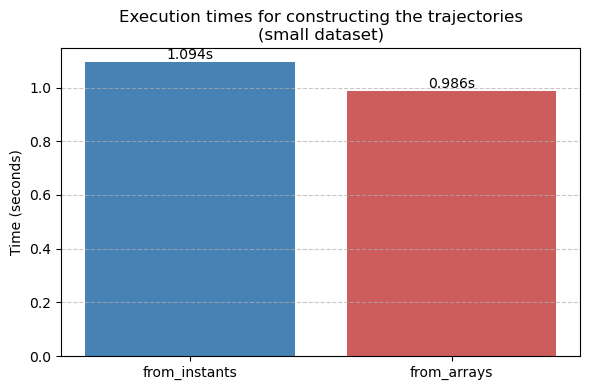

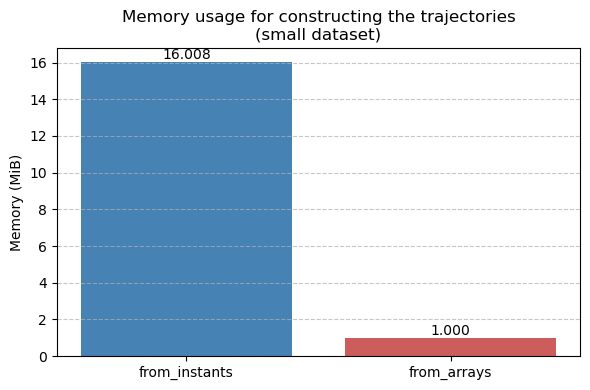

In [15]:
times = [results['extraction'][0]+ results['construction_from_instants'][0], 
         results['extraction'][0]+ results['construction_from_arrays'][0]]
mem = [results['construction_from_instants'][1], results['construction_from_arrays'][1]]
labels = ['from_instants', 'from_arrays']


plt.figure(figsize=(6, 4))
bars = plt.bar(labels, times, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for constructing the trajectories\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, mem, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}", ha='center', va='bottom')

plt.title(f"Memory usage for constructing the trajectories\n({chosen_size} dataset)")
plt.ylabel("Memory (MiB)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Check that the from_arrays and from_instants trajectories are identical

In [16]:
nb_traj_points_from_instants = [trajectories_from_instants.trajectory[i].num_instants() for i in trajectories_from_instants.index]
nb_traj_points_from_arrays = [trajectories_from_arrays.trajectory[i].num_instants() for i in trajectories_from_arrays.index]

print(sum(nb_traj_points_from_instants) == sum(nb_traj_points_from_arrays))
print(all(trajectories_from_instants == trajectories_from_arrays))

True
True
